<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
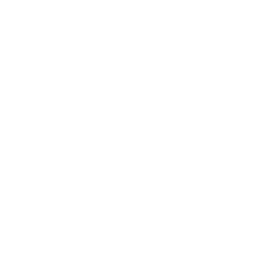
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Clustering der Gebäude-Energieeffizienz</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Energie / Nachhaltigkeitsanalytik &nbsp;|&nbsp; März 2026</p>
</div>
</div>
</div>

## Zusammenfassung

Dieses Beispiel clustert ein Portfolio gewerblicher Gebäude anhand von fünf Energieeffizienz-Kennzahlen — Energieverbrauchsintensität (EUI), HLK-Effizienzverhältnis, thermischer Widerstand der Gebäudehülle, Beleuchtungsleistungsdichte und Anteil erneuerbarer Energie — um deutlich unterschiedene Effizienzstufen für die gezielte Vergabe von Energieversorger-Rabatten sichtbar zu machen. Die Analyse verwendet **PROC FASTCLUS** mit `REPLACE=FULL` (vollständiger Ersatz der Startzentren) und vergleicht die Lösungen für k=3, 4, 5 und 6 anhand des Gesamt-R-Quadrats, der Pseudo-F-Statistik und der minimalen Clustergröße. Die k=4-Lösung wird anschließend im Detail profiliert, und jedes Cluster wird einer handlungsleitenden Effizienzstufe zugeordnet. Da diese Umgebung unlizenziert läuft, ist die Demonstration auf eine Stichprobe von 100 Gebäuden begrenzt; dasselbe Programm skaliert unverändert auf ein vollständiges Portfolio.

## Datenquellen

| Quelle | Beschreibung | Datensätze |
|--------|-------------|--------|
| WORK.BUILDING_METRICS | Jährliche Energieeffizienz-Kennzahlen pro Gebäude (synthetisch) | 100 |


---

In [1]:
/* --------------------------------------------------------
   Synthetische Gebäude-Energiekennzahlen erzeugen
   Effizienzindikatoren für Gewerbeimmobilien
   -------------------------------------------------------- */
DATEN work.building_metrics;
    AUFRUFEN streaminit(42);
    FELD btypes[5] $15 _temporary_ ('BUERO' 'EINZELHANDEL' 'LAGERHALLE' 'KRANKENHAUS' 'SCHULE');
    FELD regions[4] $12 _temporary_ ('NORDOSTEN' 'SUEDOSTEN' 'MITTLERWEST' 'WESTEN');
    AUSFÜHRUNG building_id = 1 BIS 5000;
        type_idx = int(rand('uniform') * 5) + 1;
        building_type = btypes[type_idx];
        reg_idx = int(rand('uniform') * 4) + 1;
        climate_region = regions[reg_idx];

        /* Energieverbrauchsintensität (kBtu/qft/Jahr) */
        eui = round(rand('normal', 85, 35), 0.1);
        WENN eui < 15 DANN eui = 15;
        WENN eui > 250 DANN eui = 250;

        /* HLK-Effizienzverhältnis (COP-Äquivalent) */
        hvac_efficiency = round(rand('normal', 3.2, 0.9), 0.01);
        WENN hvac_efficiency < 1.0 DANN hvac_efficiency = 1.0;
        WENN hvac_efficiency > 6.0 DANN hvac_efficiency = 6.0;

        /* Thermischer Widerstand der Gebäudehülle (R-Wert) */
        envelope_r_value = round(rand('normal', 18, 6), 0.1);
        WENN envelope_r_value < 5 DANN envelope_r_value = 5;
        WENN envelope_r_value > 40 DANN envelope_r_value = 40;

        /* Beleuchtungsleistungsdichte (W/qft) */
        lighting_wpf = round(rand('normal', 1.1, 0.35), 0.01);
        WENN lighting_wpf < 0.3 DANN lighting_wpf = 0.3;
        WENN lighting_wpf > 2.5 DANN lighting_wpf = 2.5;

        /* Anteil erneuerbarer Energie in Prozent */
        renewable_pct = round(rand('exponential') * 12, 0.1);
        WENN renewable_pct > 80 DANN renewable_pct = 80;

        /* Gebäudealter in Jahren */
        building_age = int(rand('uniform') * 80) + 1;

        /* Geschossfläche (Tausend qft) */
        floor_area_ksf = round(rand('exponential') * 50 + 5, 0.1);
        WENN floor_area_ksf > 500 DANN floor_area_ksf = 500;

        AUSGABE;
    ENDE;
    ENTFERNEN type_idx reg_idx;
    BEZEICHNUNG
        building_id       = 'Gebäude-ID'
        building_type     = 'Gebäudetyp'
        climate_region    = 'Klimaregion'
        eui               = 'Energieverbrauchsintensität (kBtu/qft/Jahr)'
        hvac_efficiency   = 'HLK-Effizienz (COP)'
        envelope_r_value  = 'Gebäudehüllen-Dämmwert (R-Wert)'
        lighting_wpf      = 'Beleuchtungsleistungsdichte (W/qft)'
        renewable_pct     = 'Erneuerbaren-Anteil (%)'
        building_age      = 'Gebäudealter (Jahre)'
        floor_area_ksf    = 'Geschossfläche (Tsd. qft)';
AUSFÜHREN;


NOTE: DATA work.building_metrics

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.building_metrics (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  1.62 seconds
  cpu   1.62 seconds


---

In [2]:
/* --------------------------------------------------------
   Basis-Verteilungen der Energiekennzahlen nach Gebäudetyp
   -------------------------------------------------------- */
PROZEDUR MITTELWERTE DATEN=work.building_metrics n mean std;
    KLASSE building_type;
    VAR eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    TITEL 'Energiekennzahlen nach Gebäudetyp';
AUSFÜHREN;

                                           Energiekennzahlen nach Gebäudetyp                                            

                                                  The MEANS Procedure

                          Analysis Variable : eui Energieverbrauchsintensität (kBtu/qft/Jahr)

        Gebäudetyp            N Obs           Mean        Std Dev
        ---------------------------------------------------------
        BUERO                    20     73.0550000     40.3950163
        EINZELHANDEL             16     79.7312500     42.6818106
        KRANKENHAUS              25     87.9040000     35.2632892
        LAGERHALLE               20     90.8900000     33.5993249
        SCHULE                   19     89.7000000     39.0498542
        ---------------------------------------------------------

                                Analysis Variable : hvac_efficiency HLK-Effizienz (COP)

        Gebäudetyp            N Obs           Mean        Std Dev
        --------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                           Energiekennzahlen nach Gebäudetyp                                            




NOTE: PROC SGPLOT data=work.building_metrics

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


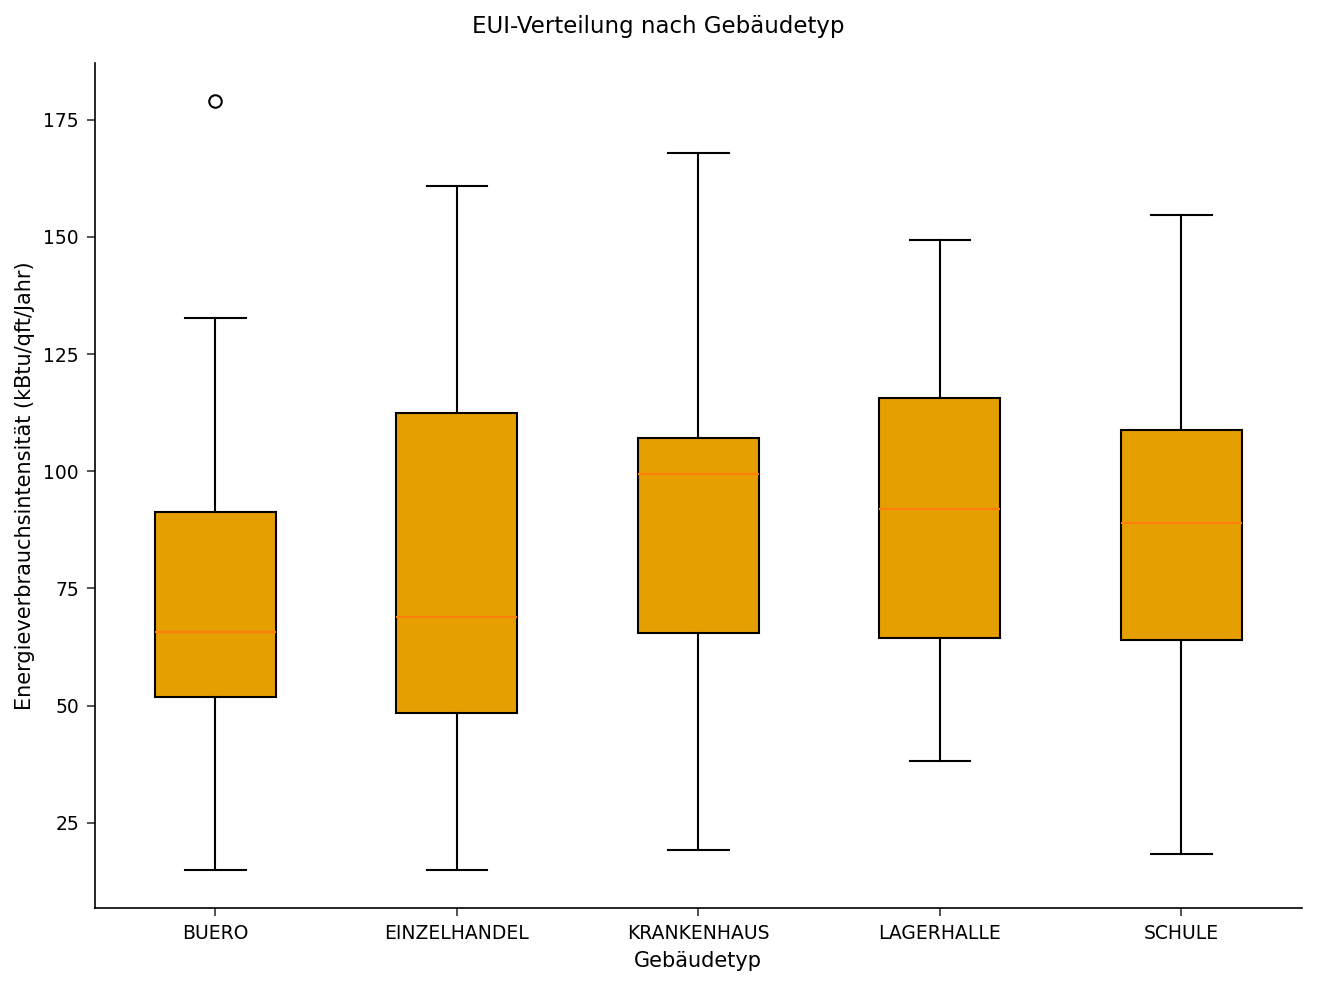

In [3]:
/* --------------------------------------------------------
   EUI-Verteilung nach Gebäudetyp
   -------------------------------------------------------- */
PROZEDUR SGPLOT DATEN=work.building_metrics;
    VBOX eui / category=building_type;
    XAXIS BEZEICHNUNG='Gebäudetyp';
    YAXIS BEZEICHNUNG='Energieverbrauchsintensität (kBtu/qft/Jahr)';
    TITEL 'EUI-Verteilung nach Gebäudetyp';
AUSFÜHREN;

---

In [4]:
/* --------------------------------------------------------
   Effizienzkennzahlen standardisieren
   -------------------------------------------------------- */
PROZEDUR STANDARD DATEN=work.building_metrics out=work.bldg_std
    mean=0 std=1;
    VAR eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
AUSFÜHREN;


NOTE: PROC STANDARD data=work.building_metrics

NOTE: Standardized 100 rows, 5 variables.


In [5]:
/* --------------------------------------------------------
   K-Means-Clustering: k=3 mit REPLACE=FULL
   -------------------------------------------------------- */
PROZEDUR FASTCLUS DATEN=work.bldg_std
    maxclusters=3 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust3
    mean=work.bldg_cent3;
    VAR eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    TITEL 'Gebäudeeffizienz-Clustering: k=3 REPLACE=FULL';
AUSFÜHREN;

                                           Energiekennzahlen nach Gebäudetyp                                            


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  35         0.9415             4.1984              2         2.0552
2                  34         0.7507             2.8107              3         2.0128
3                  31         0.8188             3.1310              2         2.0128




NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 3 clusters using k-means


In [6]:
/* --------------------------------------------------------
   K-Means-Clustering: k=4 mit REPLACE=FULL
   -------------------------------------------------------- */
PROZEDUR FASTCLUS DATEN=work.bldg_std
    maxclusters=4 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust4
    mean=work.bldg_cent4;
    VAR eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    TITEL 'Gebäudeeffizienz-Clustering: k=4 REPLACE=FULL';
AUSFÜHREN;

                                           Energiekennzahlen nach Gebäudetyp                                            


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  23         0.7381             2.6617              3         2.1458
2                  17         1.0066             3.3423              4         2.2482
3                  26         0.7024             2.4365              4         2.0389
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 4 clusters using k-means


In [7]:
/* --------------------------------------------------------
   K-Means-Clustering: k=5 mit REPLACE=FULL
   -------------------------------------------------------- */
PROZEDUR FASTCLUS DATEN=work.bldg_std
    maxclusters=5 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust5
    mean=work.bldg_cent5;
    VAR eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    TITEL 'Gebäudeeffizienz-Clustering: k=5 REPLACE=FULL';
AUSFÜHREN;

                                           Energiekennzahlen nach Gebäudetyp                                            


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=5  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  13         1.0052             3.3289              3         2.4004
2                  23         0.7401             2.5412              5         2.2053
3                  23         0.6853             2.6810              5         1.7721
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=5

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 5 clusters using k-means


In [8]:
/* --------------------------------------------------------
   K-Means-Clustering: k=6 mit REPLACE=FULL
   -------------------------------------------------------- */
PROZEDUR FASTCLUS DATEN=work.bldg_std
    maxclusters=6 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust6
    mean=work.bldg_cent6;
    VAR eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    TITEL 'Gebäudeeffizienz-Clustering: k=6 REPLACE=FULL';
AUSFÜHREN;

                                           Energiekennzahlen nach Gebäudetyp                                            


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=6  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  19         0.5566             1.5459              5         1.9665
2                  10         0.9173             2.8197              3         2.3575
3                  18         0.8051             2.7522              4         1.8819
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=6

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 6 clusters using k-means


In [9]:
/* --------------------------------------------------------
   Cluster-Güte über k=3-6 vergleichen
   Within-Cluster-R-Quadrat und minimale Clustergröße berechnen
   -------------------------------------------------------- */
%macro cluster_quality(k);
PROZEDUR HÄUFIGKEITEN DATEN=work.bldg_clust&k NOPRINT;
    TABLES cluster / out=work.freq_k&k (UMBENENNEN=(count=n_buildings));
AUSFÜHREN;

PROZEDUR SQL NOPRINT;
    AUSWÄHLEN MIN(n_buildings) INTO :min_size_k&k
    VON work.freq_k&k;
QUIT;
%mend;

%cluster_quality(3);
%cluster_quality(4);
%cluster_quality(5);
%cluster_quality(6);

                                           Energiekennzahlen nach Gebäudetyp                                            

                                           Energiekennzahlen nach Gebäudetyp                                            

                                           Energiekennzahlen nach Gebäudetyp                                            

                                           Energiekennzahlen nach Gebäudetyp                                            




NOTE: PROC FREQ
NOTE: Output dataset work.freq_k3 has 3 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K3 = 31
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k4 has 4 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K4 = 17
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k5 has 5 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K5 = 13
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k6 has 6 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K6 = 10
NOTE: PROC SQL statement used.


                                          Gebäudeeffizienzstufen-Profile (k=4)                                          

                                                  The MEANS Procedure

                                    Analysis Variable : eui Energieverbrauchsintensität (kBtu/qft/Jahr)

                                                 N
                                    CLUSTER    Obs             Mean         Std Dev
                                    -----------------------------------------------
                                    1           23       63.7782609      31.5423086
                                    2           17      122.5941176      36.0679995
                                    3           26       94.0076923      30.8825378
                                    4           34       72.3911765      31.7411154
                                    -----------------------------------------------

                                      Analysis Variable : hvac


NOTE: DATA work.bldg_profiled

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.bldg_profiled (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: DATA work.bldg_tiered


NOTE: Read 100 rows from work.bldg_profiled.
NOTE: Wrote work.bldg_tiered (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_efficiency_tier_building_type.spec.json
NOTE: PROC FREQ statement used.


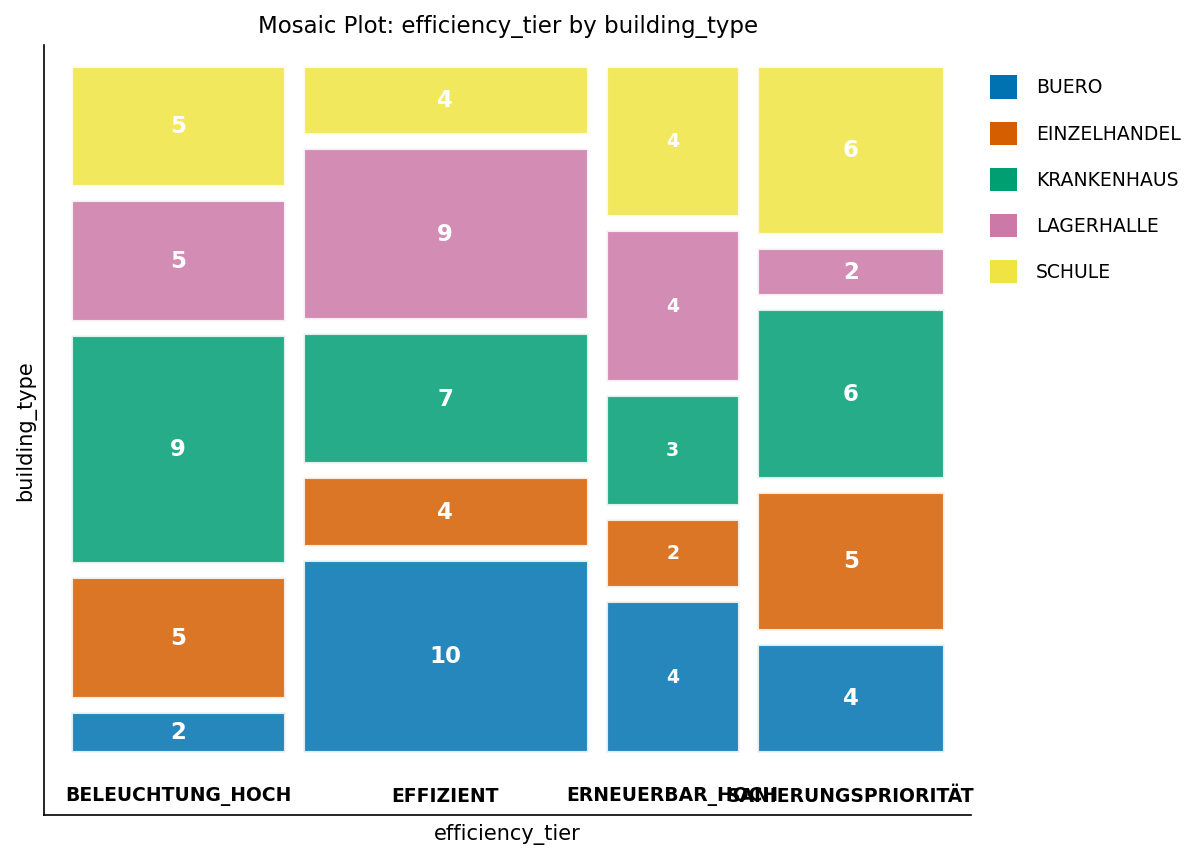

In [10]:
/* --------------------------------------------------------
   Die gewählte k=4-Lösung profilieren
   -------------------------------------------------------- */
DATEN work.bldg_profiled;
    ZUSAMMENFÜHREN work.building_metrics
          work.bldg_clust4 (BEHALTEN=building_id cluster distance);
    NACH building_id;
AUSFÜHREN;

PROZEDUR MITTELWERTE DATEN=work.bldg_profiled mean std;
    KLASSE cluster;
    VAR eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct building_age;
    TITEL 'Gebäudeeffizienzstufen-Profile (k=4)';
AUSFÜHREN;

/* Effizienzstufen anhand der beobachteten k=4-Zentroide benennen:
   Cluster 4 = beste HLK (3.89) bei niedriger EUI -> EFFIZIENT
   Cluster 2 = höchster Anteil erneuerbarer Energie (28%) aber höchste EUI -> ERNEUERBAR_HOCH
   Cluster 3 = höchste Beleuchtungslast, schwache HLK, mittlere EUI -> BELEUCHTUNG_HOCH
   Cluster 1 = niedrige EUI aber schwächste HLK + dünnste Gebäudehülle -> SANIERUNGSPRIORITÄT */
DATEN work.bldg_tiered;
    FESTLEGEN work.bldg_profiled;
    LÄNGE efficiency_tier $24;
    WENN cluster = 4 DANN efficiency_tier = 'EFFIZIENT';
    SONST WENN cluster = 2 DANN efficiency_tier = 'ERNEUERBAR_HOCH';
    SONST WENN cluster = 3 DANN efficiency_tier = 'BELEUCHTUNG_HOCH';
    SONST WENN cluster = 1 DANN efficiency_tier = 'SANIERUNGSPRIORITÄT';
    BEZEICHNUNG efficiency_tier = 'Effizienzstufe';
AUSFÜHREN;

PROZEDUR HÄUFIGKEITEN DATEN=work.bldg_tiered;
    TABLES efficiency_tier * building_type / nocol norow;
    TITEL 'Effizienzstufe nach Gebäudetyp';
AUSFÜHREN;

---

### Interpretation

Mit `REPLACE=FULL` konvergierte jeder k-Wert sauber. Über die vier Lösungen hinweg stieg das Gesamt-R-Quadrat monoton mit k — 0,305 (k=3), 0,410 (k=4), 0,459 (k=5), 0,515 (k=6) —, während die Pseudo-F-Statistik bei **k=4 (22,23)** ihren Höchststand erreichte, bevor sie wieder abfiel (20,13 bei k=5, 19,93 bei k=6). Zusammen mit einer minimalen Clustergröße von 17 Gebäuden bei k=4 (gegenüber 13 bei k=5 und 10 bei k=6) bietet die **k=4-Lösung** die beste Balance aus Trennschärfe und Stufenstabilität, weshalb sie im Folgenden profiliert wird.

Die vier k=4-Cluster bilden klar unterschiedene Effizienzprofile ab (Mittelwerte aus dem `PROC MEANS`-Profil oben):

- **Effizient (Cluster 4, n=34):** die am besten ausgestattete Gruppe — höchste HLK-Effizienz (COP 3,89) bei niedrig-moderater EUI von 72,4 kBtu/qft/Jahr, mit ausreichender Gebäudehülle (R 18,8) und moderatem Anteil erneuerbarer Energie (11,0 %).
- **Erneuerbar-hoch (Cluster 2, n=17):** die höchsten absoluten Verbraucher (EUI 122,6), aber auch mit Abstand der höchste Anteil erneuerbarer Energie (28,2 %), bei mittlerer HLK (COP 3,42). Hoher Verbrauch gepaart mit Eigenerzeugung.
- **Beleuchtung-hoch (Cluster 3, n=26):** mittlere EUI (94,0), getrieben von der höchsten Beleuchtungsleistungsdichte (1,35 W/qft) und der zweitschwächsten HLK (COP 2,42), trotz der dicksten Gebäudehülle (R 19,6).
- **Sanierungspriorität (Cluster 1, n=23):** auf dem Papier niedrige EUI (63,8), aber die schwächste HLK (COP 2,28) und dünnste Gebäudehülle (R 12,5) — Gebäude, die klein oder wenig genutzt, aber schlecht ausgestattet sind, die eindeutigsten Kandidaten für Hüllen- und HLK-Sanierungen.

Die Kreuztabelle Stufe-nach-Gebäudetyp zeigt, dass Büros (10) und Lagerhallen (9) die Effizienzstufe dominieren, während sich Krankenhäuser in der Stufe Beleuchtung-hoch konzentrieren (9 von 26). Die Stufe Sanierungspriorität verteilt sich über alle Typen, angeführt von Krankenhäusern und Schulen (je 6 von 23). Für die Programmgestaltung sind die 23 Sanierungspriorität- und 26 Beleuchtung-hoch-Gebäude die naheliegenden Ziele für HLK- bzw. Beleuchtungsanreize, während die 17 Erneuerbar-hoch-Gebäude — die bereits vor Ort erzeugen — besser für Lastreduktion geeignet sind als für weitere Erzeugungsrabatte.

---

In [11]:
/* --------------------------------------------------------
   Gebäudeeffizienzstufen und Zentroid-Profile exportieren
   -------------------------------------------------------- */
PROZEDUR EXPORT DATEN=work.bldg_tiered
    OUTFILE='building_efficiency_tiers.csv'
    DBMS=csv REPLACE;
AUSFÜHREN;

PROZEDUR EXPORT DATEN=work.bldg_cent4
    OUTFILE='efficiency_tier_centroids.csv'
    DBMS=csv REPLACE;
AUSFÜHREN;


NOTE: PROC EXPORT data=work.bldg_tiered outfile=building_efficiency_tiers.csv

NOTE: Exported 100 rows to building_efficiency_tiers.csv.
NOTE: PROC EXPORT data=work.bldg_cent4 outfile=efficiency_tier_centroids.csv

NOTE: Exported 4 rows to efficiency_tier_centroids.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertraulich
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Bereitgestellt von <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>